In [1]:
import pandas as pd
import torch
import librosa
import os
from tsai.all import *


# Load in Music Data
music_dta_3 = pd.read_csv('/Users/tarush/Desktop/STA 395/ML_Music_Genre-main/Data/music_with_labels_3_genres.csv')

# Load in base model
net_3 = InceptionTime(1, 3)

# Create additional variables 
path = '/Users/tarush/Desktop/STA 395/ML_Music_Genre-main/Data/Music/genres_original' 
music_dta_3["Audio_pth"] = path + "/" + music_dta_3["Label"] + "/" + music_dta_3["Audio"]
music_dta_3['Audio_y_dta'] = (music_dta_3['Audio_pth'].map(librosa.load))


In [2]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

bsize = 32

def grab_first(inp):
    return (inp[0])[300000:360000]

music_dta_3['Audio_y_dta_arr'] = music_dta_3['Audio_y_dta'].apply(grab_first)

# Split data to create training, validation, and testing set
music_dta_3_train, music_dta_3_test = train_test_split(music_dta_3, test_size=0.4)
music_dta_3_validate, music_dta_3_test = train_test_split(music_dta_3_test, test_size=0.5)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(music_dta_3_train["Label"])

music_dta_3_train_y = torch.tensor(
    le.transform(music_dta_3_train["Label"]),
    dtype=torch.long
)

music_dta_3_validate_y = torch.tensor(
    le.transform(music_dta_3_validate["Label"]),
    dtype=torch.long
)

music_dta_3_test_y = torch.tensor(
    le.transform(music_dta_3_test["Label"]),
    dtype=torch.long
)


# tensor data for train loader
music_dta_3_train['Audio_y_dta_arr'] = music_dta_3_train['Audio_y_dta_arr'].apply(torch.Tensor)

# music_dta_3_train['Label_num'], unique_categories = pd.factorize(music_dta_3_train["Label"]) # Stack Overflow
# music_dta_3_train_y = torch.Tensor(tuple(music_dta_3_train["Label_num"].to_numpy()))

music_dta_3_train_X = torch.stack(tuple(music_dta_3_train['Audio_y_dta_arr'])).unsqueeze(1)

# train_loader = DataLoader(TensorDataset(music_dta_3_train_X.type(torch.FloatTensor), music_dta_3_train_y.type(torch.LongTensor)), batch_size=bsize)
train_loader = DataLoader(
    TensorDataset(music_dta_3_train_X.float(), music_dta_3_train_y),
    batch_size=bsize,
    shuffle=True
)


# tensor data for validate loader
music_dta_3_validate['Audio_y_dta_arr'] = music_dta_3_validate['Audio_y_dta_arr'].apply(torch.Tensor)

# music_dta_3_validate['Label_num'], unique_categories = pd.factorize(music_dta_3_validate["Label"]) # Stack Overflow
# music_dta_3_validate_y = torch.Tensor(tuple(music_dta_3_validate["Label_num"].to_numpy()))
music_dta_3_validate_X = torch.stack(tuple(music_dta_3_validate['Audio_y_dta_arr'])).unsqueeze(1)

validate_loader = DataLoader(TensorDataset(music_dta_3_validate_X.type(torch.FloatTensor), music_dta_3_validate_y.type(torch.LongTensor)), batch_size=bsize)

In [3]:
# tensor data for test loader
music_dta_3_test['Audio_y_dta_arr'] = music_dta_3_test['Audio_y_dta_arr'].apply(torch.Tensor)

# music_dta_3_test['Label_num'], unique_categories = pd.factorize(music_dta_3_test["Label"]) # Stack Overflow
# music_dta_3_test_y = torch.Tensor(tuple(music_dta_3_test["Label_num"].to_numpy()))
music_dta_3_test_X = torch.stack(tuple(music_dta_3_test['Audio_y_dta_arr'])).unsqueeze(1)

test_loader = DataLoader(TensorDataset(music_dta_3_test_X.type(torch.FloatTensor), music_dta_3_test_y.type(torch.LongTensor)), batch_size=bsize)

In [ ]:
## =========================
## Hyperparams + Model Setup
## =========================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(20)

epochs = 10 #12
lrate = 0.05 #0.002

cost_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net_3.parameters(), lr=lrate)

track_cost = np.zeros(epochs)
track_val_cost = np.zeros(epochs)

# stop = False  # OLD (unused)

## =========================
## DataLoaders (fix shuffle)
## =========================
# OLD: train_loader = DataLoader(..., batch_size=bsize)
# Make sure you created music_dta_3_train_X and music_dta_3_train_y earlier
# If your train_loader already exists, you can ignore this. Otherwise, use this:
from torch.utils.data import DataLoader, TensorDataset

# IMPORTANT: reduce batch size if you still hit memory pressure
# bsize = 32  # OLD
bsize = 8

train_loader = DataLoader(
    TensorDataset(music_dta_3_train_X.float(), music_dta_3_train_y),
    batch_size=bsize,
    shuffle=True
)

validate_loader = DataLoader(
    TensorDataset(music_dta_3_validate_X.float(), music_dta_3_validate_y),
    batch_size=bsize,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(music_dta_3_test_X.float(), music_dta_3_test_y),
    batch_size=bsize,
    shuffle=False
)

## =========================
## TRAIN + VALID LOOP (FIXED)
## =========================
for epoch in range(epochs):
    print(f"Epoch {epoch}")

    # ----- TRAIN -----
    net_3.train()
    cur_cost = 0.0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = net_3(inputs)

        # OLD (wrong): cost = cost_fn(nn.Softmax(dim=1)(outputs), labels)
        # OLD (bug):   cost = cost_fn(val_outputs, labels)
        cost = cost_fn(outputs, labels)

        cost.backward()
        optimizer.step()

        cur_cost += cost.item()

        # OLD VALIDATION LOOP (WRONG PLACE — runs every train batch; huge slow/memory):
        # for i, data in enumerate(validate_loader, 0):
        #     inputs, labels = data
        #     val_outputs = net_3(inputs)
        #     val_cost = cost_fn(nn.Softmax(dim=1)(val_outputs), labels)
        #     val_cur_cost += val_cost.item()

        # OLD "moved" validation (still wrong because it was INSIDE train loop):
        # net_3.eval()
        # val_cur_cost = 0.0
        # with torch.no_grad():
        #     for inputs, labels in validate_loader:
        #         val_outputs = net_3(inputs)
        #         val_cost = cost_fn(val_outputs, labels)
        #         val_cur_cost += val_cost.item()
        # net_3.train()

    # ----- VALIDATE (ONCE PER EPOCH) -----
    net_3.eval()
    val_cur_cost = 0.0
    with torch.no_grad():
        for vinputs, vlabels in validate_loader:
            voutputs = net_3(vinputs)
            vcost = cost_fn(voutputs, vlabels)
            val_cur_cost += vcost.item()

    print("Train_Cost:", cur_cost)
    print("Val_Cost:", val_cur_cost)

    track_cost[epoch] = cur_cost
    track_val_cost[epoch] = val_cur_cost

    # OLD early stopping logic (kept but commented; we can re-add cleanly later):
    # if epoch > 5:
    #     if track_val_cost[epoch] > track_val_cost[epoch - 1] - 0.3:
    #         break

## =========================
## Plot cost curves
## =========================
plt.plot(np.arange(epochs), track_cost, label="train")
plt.plot(np.arange(epochs), track_val_cost, label="val")
plt.legend()
plt.show()

## =========================
## Accuracy helper
## =========================
def accuracy(loader):
    correct = 0
    total = 0
    net_3.eval()
    with torch.no_grad():
        for x, y in loader:
            out = net_3(x)
            _, pred = torch.max(out.data, 1)
            total += y.size(0)
            correct += (pred == y).sum().item()
    return correct / total if total > 0 else 0.0

print("Train accuracy:", accuracy(train_loader))
print("Test  accuracy:", accuracy(test_loader))

Epoch 0
Train_Cost: 34.56598764657974
Val_Cost: 7.4913212060928345
Epoch 1
Train_Cost: 22.091534197330475
Val_Cost: 7.440612077713013
Epoch 2
Train_Cost: 21.336032450199127
Val_Cost: 8.250333905220032
Epoch 3
Train_Cost: 23.01363116502762
Val_Cost: 7.858238160610199
Epoch 4
Train_Cost: 21.425290644168854
Val_Cost: 9.78448235988617
Epoch 5


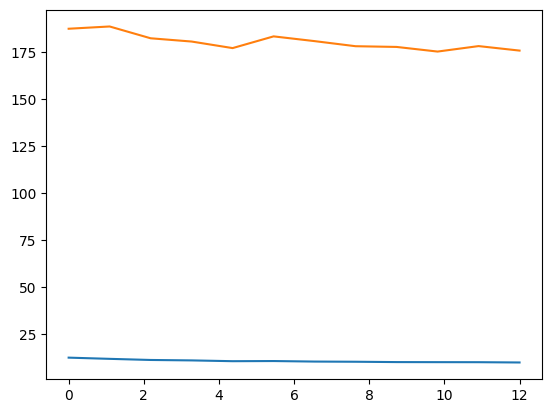

In [ ]:
## Print the cost curve
import matplotlib.pyplot as plt
plt.plot(np.linspace(0, epochs, epochs), track_cost)
plt.show()

In [ ]:
## Initialize objects for counting correct/total 
correct = 0
total = 0

# Specify no changes to the gradient in the subsequent steps (since we're not using these data for training)
with torch.no_grad():
    for data in train_loader:
        # Current batch of data
        images, labels = data
        
        # pass each batch into the network
        outputs = net_3(images)
        
        # the class with the maximum score is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        
        # add size of the current batch
        total += labels.size(0)
        
        # add the number of correct predictions in the current batch
        correct += (predicted == labels).sum().item()

## Calculate and print the proportion correct
print(correct/total)

0.7222222222222222


In [ ]:
## Initialize objects for counting correct/total 
correct = 0
total = 0

# Specify no changes to the gradient in the subsequent steps (since we're not using these data for training)
with torch.no_grad():
    for data in test_loader:
        # Current batch of data
        input, labels = data
        
        # pass each batch into the network
        outputs = net_3(input)
        
        # the class with the maximum score is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        
        # add size of the current batch
        total += labels.size(0)
        
        # add the number of correct predictions in the current batch
        correct += (predicted == labels).sum().item()

## Calculate and print the proportion correct
print(correct/total)

0.1
